# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: Importar a DataFrame de um arquivo CSV. Instanciar uma DataFrame nova contendo as colunas da DataFrame importada. Concatenar as 2 DataFrames Definir uma função quem recebe a série e divide cada um dos valores pelo valor da soma dos valores. Inserir essa coluna na DataFrame. Usando uma estrutura de repetição é instanciar a lista com o acumulado dos valores de frequência. Instanciar uma lista contendo todos os valores menos o total. Instanciar uma lista contendo as cores. Utilizando uma estrutura de repetição definir um gráfico contendo cada uma das instâncias, usando a coluna frequência relativa simples, valores menos o total, cores e parâmetro bottom recebendo valor acumulado.

## 02 – Desenhe o fluxograma da resposta:

<img src="./img/13-fluxograma_exercício2.png" width="600" />

## 03 – Escreva o programa em Python:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_genes = pd.read_csv("./data/df_genes_aula6exer7.csv", index_col="Unnamed: 0")
df_genes.head()

,num_letras,primeiras_duas_letras,num_a,contains_hu
isg15,5,is,0,False
hur,3,hu,0,True
ifna,4,if,1,False
tnfa,4,tn,1,False
atpsf1a,7,at,2,False


In [3]:
df_num_letras = df_genes.num_letras.to_frame()
df_num_letras.loc["Total", "num_letras"] = df_num_letras.num_letras.sum()
df_num_letras

,num_letras
isg15,5.0
hur,3.0
ifna,4.0
tnfa,4.0
atpsf1a,7.0
Total,23.0


In [4]:
df_genes_nominal = df_num_letras.copy()
df_genes_nominal["Freq Relat Simp"] = df_num_letras/df_num_letras.loc["Total", "num_letras"]
df_genes_nominal.rename(columns={"num_letras": "Freq Absol Simp"}, inplace=True)
df_genes_nominal = df_genes_nominal.round(2)
df_genes_nominal

,Freq Absol Simp,Freq Relat Simp
isg15,5.0,0.22
hur,3.0,0.13
ifna,4.0,0.17
tnfa,4.0,0.17
atpsf1a,7.0,0.30
Total,23.0,1.00


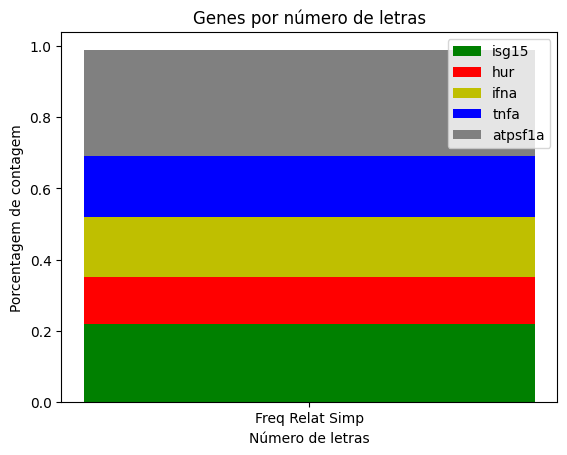

In [5]:
coluna = df_genes_nominal.columns[1]  # Assuming 'Freq Relat Simpl' is the second column
a, b, c, d, e, _ = df_genes_nominal[coluna].values

plt.bar(coluna, a, color='g')
plt.bar(coluna, b, color='r', bottom=a)
plt.bar(coluna, c, color='y', bottom=a+b)
plt.bar(coluna, d, color='b', bottom=a+b+c)
plt.bar(coluna, e, color='grey', bottom=a+b+c+d)
plt.legend(df_genes_nominal[coluna].index)
plt.ylabel('Porcentagem de contagem')
plt.xlabel('Número de letras')
plt.title('Genes por número de letras')
plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: Definir uma função para fazer o cálculo da frequência acumulada. Essa função recebe uma lista ou uma série, que vai ser iterada por uma estrutura de repetição, onde cada valor vai ser incrementado a ele mesmo. Esse resultado é inserido numa lista que recebe ao final np.nan. Retorna ao usuário. Usar essa função para inserir a frequência absoluta acumulada na DataFrame. Usando a função do cálculo de frequência relativa do exercício anterior inserir o valor na DataFrame. Utilizando o plt, instanciar um gráfico de linhas com a frequência absoluta simples e no mesmo gráfico a frequência absoluta acumulada. Repetir o mesmo gráfico com a frequência relativa a simples e a frequência relativa acumulada. Intânciar o gráfico de barras com o catplot do seaborn com os mesmos parâmetros.

## 05 – Desenhe o fluxograma da resposta:

<img src="./img/13-fluxograma_exercício4.png" width="600" />

## 06 – Escreva o programa em Python:

In [6]:
df_genes_ordinal = df_genes_nominal.copy()
df_genes_ordinal['Freq Absol Acum'] = df_genes_nominal['Freq Absol Simp'].cumsum()
df_genes_ordinal['Freq Relat Acum'] = df_genes_ordinal["Freq Absol Acum"] / df_genes_ordinal.loc["Total", "Freq Absol Simp"]
df_genes_ordinal.iloc[-1, [2, 3]] = np.nan
df_genes_ordinal = df_genes_ordinal.round(2)
df_genes_ordinal

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum
isg15,5.0,0.22,5.0,0.22
hur,3.0,0.13,8.0,0.35
ifna,4.0,0.17,12.0,0.52
tnfa,4.0,0.17,16.0,0.70
atpsf1a,7.0,0.30,23.0,1.00
Total,23.0,1.00,NaN,NaN


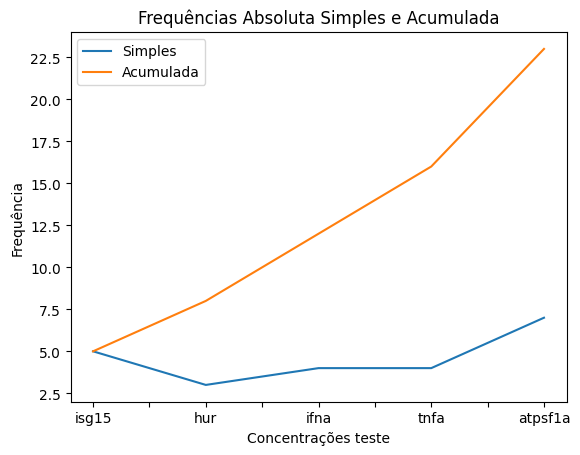

In [7]:
df_genes_ordinal.iloc[:-1][[df_genes_ordinal.columns[0],df_genes_ordinal.columns[2]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Absoluta Simples e Acumulada")
plt.legend(['Simples', 'Acumulada'])
plt.show()

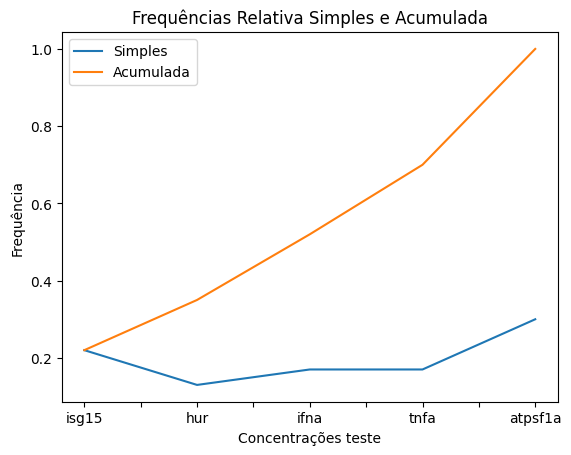

In [8]:
df_genes_ordinal.iloc[:-1][[df_genes_ordinal.columns[1],df_genes_ordinal.columns[3]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Simples e Acumulada")
plt.legend(['Simples', 'Acumulada'])
plt.show()

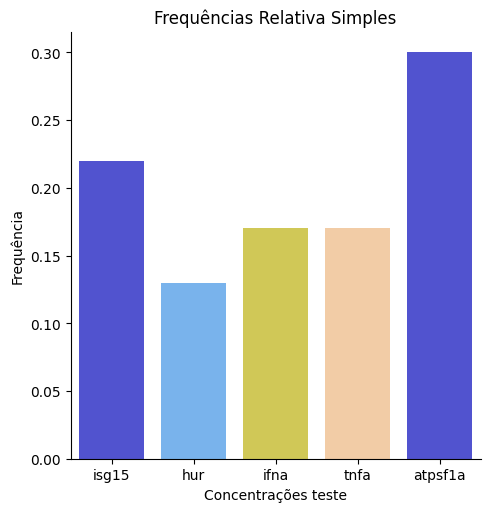

In [9]:
custom_palette = ["#3C3FE4", '#66B3FF', "#E4D943", '#FFCC99']  # Custom pastel colors
sns.catplot(
    kind='bar',
    x=list(df_genes_ordinal['Freq Relat Simp'].index)[:-1],
    y='Freq Relat Simp',
    data=df_genes_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Simples")
plt.show()

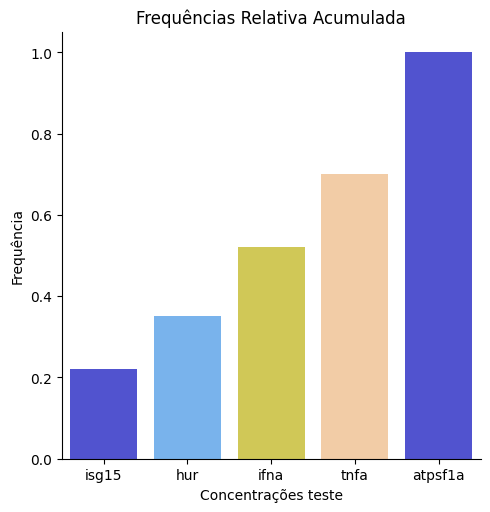

In [10]:
sns.catplot(
    kind='bar',
    x=list(df_genes_ordinal['Freq Relat Acum'].index)[:-1],
    y='Freq Relat Acum',
    data=df_genes_ordinal.iloc[:-1],
    palette=custom_palette
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência")
plt.title("Frequências Relativa Acumulada")

plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [11]:
df_genes_ordinal_amostral_1 = df_genes_ordinal.copy()
df_genes_ordinal_amostral_1['Amostras'] = "Amostra 1"
df_genes_ordinal_amostral_1

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Amostras
isg15,5.0,0.22,5.0,0.22,Amostra 1
hur,3.0,0.13,8.0,0.35,Amostra 1
ifna,4.0,0.17,12.0,0.52,Amostra 1
tnfa,4.0,0.17,16.0,0.70,Amostra 1
atpsf1a,7.0,0.30,23.0,1.00,Amostra 1
Total,23.0,1.00,NaN,NaN,Amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [12]:
def instanciar_tabela_freq(nome_replica: str) -> pd.DataFrame:
    '''
        Instancia uma tabela de frequência para uma réplica específica.
            Parâmetros:
                nome_replica (str): O nome da réplica para a qual a
                                    tabela de frequência será instanciada.
            Retorna:
                pd.DataFrame: Uma tabela de frequência inicializada
                                para a réplica especificada.
    '''
    tabela_freq = pd.DataFrame(data=np.nan, columns=df_genes_ordinal.columns, index=df_genes_ordinal.index)
    tabela_freq.iloc[:-1, 0] = np.random.randint(1,10,5)
    tabela_freq.iloc[-1, 0] = tabela_freq["Freq Absol Simp"].sum()
    tabela_freq['Freq Relat Simp'] = tabela_freq['Freq Absol Simp'] / tabela_freq.loc["Total", "Freq Absol Simp"]
    tabela_freq['Freq Absol Acum'] = tabela_freq['Freq Absol Simp'].cumsum()
    tabela_freq['Freq Relat Acum'] = tabela_freq['Freq Absol Acum'] / tabela_freq.loc["Total", "Freq Absol Simp"]
    tabela_freq.iloc[-1, [2, 3]] = np.nan
    tabela_freq = tabela_freq.round(2)
    tabela_freq['Amostras'] = nome_replica
    return tabela_freq

In [13]:
df_genes_ordinal_amostral_2 = instanciar_tabela_freq("Amostra 2")
df_genes_ordinal_amostral_2

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Amostras
isg15,8.0,0.25,8.0,0.25,Amostra 2
hur,8.0,0.25,16.0,0.50,Amostra 2
ifna,6.0,0.19,22.0,0.69,Amostra 2
tnfa,3.0,0.09,25.0,0.78,Amostra 2
atpsf1a,7.0,0.22,32.0,1.00,Amostra 2
Total,32.0,1.00,NaN,NaN,Amostra 2


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [14]:
df_genes_ordinal_amostral_3 = instanciar_tabela_freq("Amostra 3")
df_genes_ordinal_amostral_4 = instanciar_tabela_freq("Amostra 4")
df_genes_ordinal_amostral_5 = instanciar_tabela_freq("Amostra 5")
df_genes_ordinal_amostral_6 = instanciar_tabela_freq("Amostra 6")

dfs = (
    df_genes_ordinal_amostral_1,
    df_genes_ordinal_amostral_2,
    df_genes_ordinal_amostral_3,
    df_genes_ordinal_amostral_4,
    df_genes_ordinal_amostral_5,
    df_genes_ordinal_amostral_6,
)
display(dfs)

(         Freq Absol Simp  Freq Relat Simp  Freq Absol Acum  Freq Relat Acum  \
 isg15                5.0             0.22              5.0             0.22   
 hur                  3.0             0.13              8.0             0.35   
 ifna                 4.0             0.17             12.0             0.52   
 tnfa                 4.0             0.17             16.0             0.70   
 atpsf1a              7.0             0.30             23.0             1.00   
 Total               23.0             1.00              NaN              NaN   
 
           Amostras  
 isg15    Amostra 1  
 hur      Amostra 1  
 ifna     Amostra 1  
 tnfa     Amostra 1  
 atpsf1a  Amostra 1  
 Total    Amostra 1  ,
          Freq Absol Simp  Freq Relat Simp  Freq Absol Acum  Freq Relat Acum  \
 isg15                8.0             0.25              8.0             0.25   
 hur                  8.0             0.25             16.0             0.50   
 ifna                 6.0             0.19 

## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

In [15]:
df_genes_ordinais_1 = pd.concat(dfs, axis=0).dropna().reset_index()
df_genes_ordinais_1['Replicas'] = "Réplica 1"
df_genes_ordinais_1.head()

,index,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Amostras,Replicas
0,isg15,5.0,0.22,5.0,0.22,Amostra 1,Réplica 1
1,hur,3.0,0.13,8.0,0.35,Amostra 1,Réplica 1
2,ifna,4.0,0.17,12.0,0.52,Amostra 1,Réplica 1
3,tnfa,4.0,0.17,16.0,0.70,Amostra 1,Réplica 1
4,atpsf1a,7.0,0.30,23.0,1.00,Amostra 1,Réplica 1


In [16]:
df_genes_ordinais_2 = pd.concat((
    instanciar_tabela_freq("Amostra 1"),
    instanciar_tabela_freq("Amostra 2"),
    instanciar_tabela_freq("Amostra 3"),
    instanciar_tabela_freq("Amostra 4"),
    instanciar_tabela_freq("Amostra 5"),
    instanciar_tabela_freq("Amostra 6"),
), axis=0).dropna().reset_index()
df_genes_ordinais_2['Replicas'] = "Réplica 2"
df_genes_ordinais_2.head()

,index,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Amostras,Replicas
0,isg15,7.0,0.27,7.0,0.27,Amostra 1,Réplica 2
1,hur,9.0,0.35,16.0,0.62,Amostra 1,Réplica 2
2,ifna,2.0,0.08,18.0,0.69,Amostra 1,Réplica 2
3,tnfa,5.0,0.19,23.0,0.88,Amostra 1,Réplica 2
4,atpsf1a,3.0,0.12,26.0,1.00,Amostra 1,Réplica 2


In [17]:
df_genes_ordinais_3 = pd.concat((
    instanciar_tabela_freq("Amostra 1"),
    instanciar_tabela_freq("Amostra 2"),
    instanciar_tabela_freq("Amostra 3"),
    instanciar_tabela_freq("Amostra 4"),
    instanciar_tabela_freq("Amostra 5"),
    instanciar_tabela_freq("Amostra 6"),
), axis=0).dropna().reset_index()
df_genes_ordinais_3['Replicas'] = "Réplica 3"
df_genes_ordinais_3.head()

,index,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Amostras,Replicas
0,isg15,1.0,0.06,1.0,0.06,Amostra 1,Réplica 3
1,hur,8.0,0.50,9.0,0.56,Amostra 1,Réplica 3
2,ifna,2.0,0.12,11.0,0.69,Amostra 1,Réplica 3
3,tnfa,1.0,0.06,12.0,0.75,Amostra 1,Réplica 3
4,atpsf1a,4.0,0.25,16.0,1.00,Amostra 1,Réplica 3


In [18]:
df_genes_ordinais_final = pd.concat((
    df_genes_ordinais_1,
    df_genes_ordinais_2,
    df_genes_ordinais_3
), axis=0)
df_genes_ordinais_final.head()

,index,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Amostras,Replicas
0,isg15,5.0,0.22,5.0,0.22,Amostra 1,Réplica 1
1,hur,3.0,0.13,8.0,0.35,Amostra 1,Réplica 1
2,ifna,4.0,0.17,12.0,0.52,Amostra 1,Réplica 1
3,tnfa,4.0,0.17,16.0,0.70,Amostra 1,Réplica 1
4,atpsf1a,7.0,0.30,23.0,1.00,Amostra 1,Réplica 1


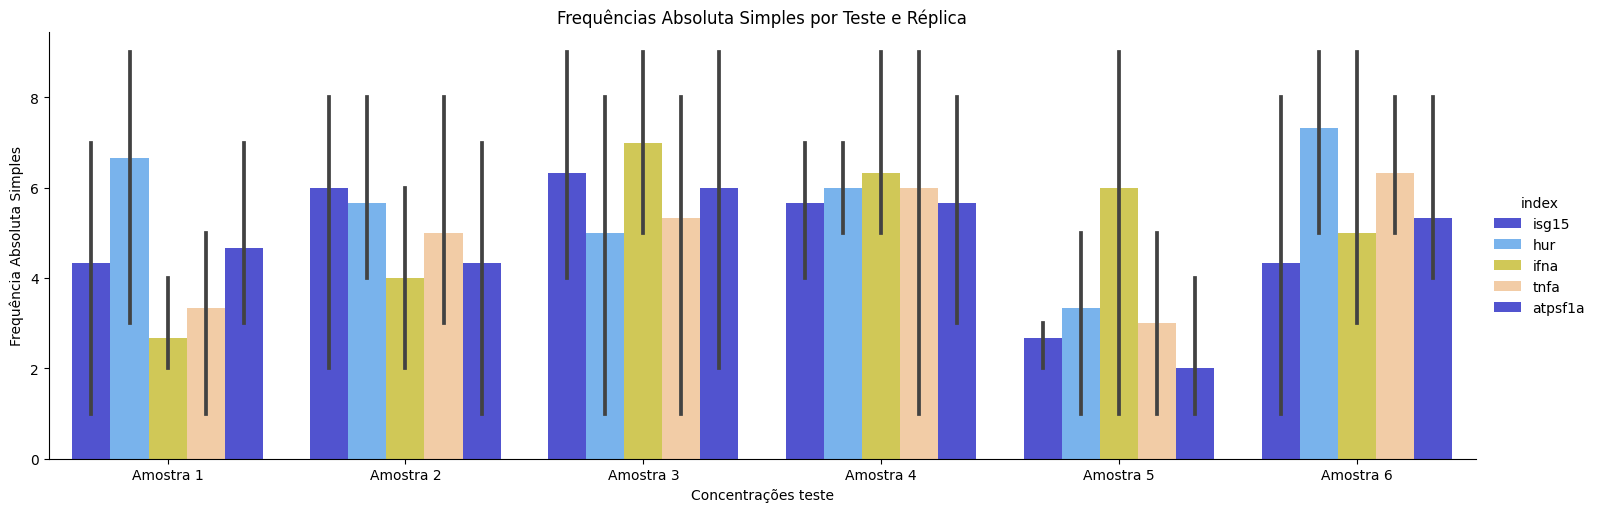

In [19]:
sns.catplot(
    kind='bar',
    x='Amostras',
    y='Freq Absol Simp',
    hue='index',
    palette=custom_palette,
    height=5,
    aspect=3,
    data=df_genes_ordinais_final,
)
plt.xlabel("Concentrações teste")
plt.ylabel("Frequência Absoluta Simples")
plt.title("Frequências Absoluta Simples por Teste e Réplica")
plt.show()